<a href="https://colab.research.google.com/github/MiliRana/assignment-01-STU2511975/blob/main/embeddings_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install sentence-transformers matplotlib seaborn

In [2]:
sentences = [
    # Cricket
    "The batsman scored a century in the final match.",
    "The bowler took five wickets in the game.",
    "The team celebrated their victory after a thrilling match.",

    # Cooking
    "I prepared a delicious pasta with fresh ingredients.",
    "Baking a cake requires precise measurements.",
    "The chef added spices to enhance the flavor.",

    # Cybersecurity
    "Strong passwords help protect user accounts.",
    "Phishing attacks can steal sensitive information.",
    "Encryption ensures data privacy and security.",

    # Extra sentence (to make 10)
    "Firewalls are used to prevent unauthorized access to networks."
]

In [3]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [4]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

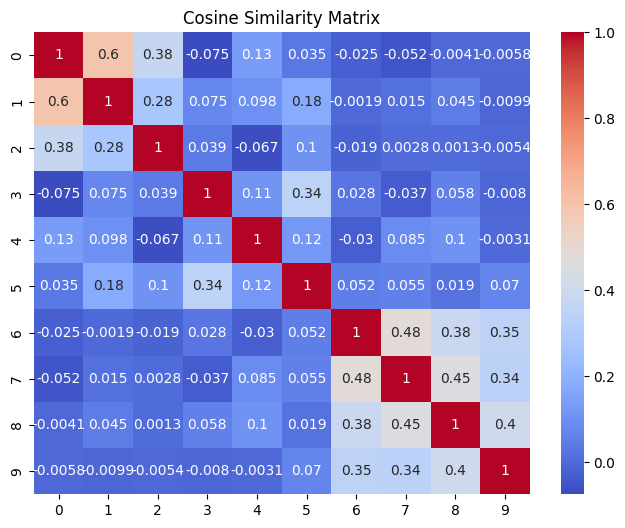

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(similarity_matrix, annot=True, cmap='coolwarm')
plt.title("Cosine Similarity Matrix")
plt.show()

In [6]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

In [7]:
import numpy as np

top_indices = np.argsort(similarities)[-2:][::-1]

print("Query:", query)
print("\nTop 2 most similar sentences:\n")

for i in top_indices:
    print(f"Sentence: {sentences[i]}")
    print(f"Similarity Score: {similarities[i]:.4f}\n")

Query: The bowler took three wickets in one over

Top 2 most similar sentences:

Sentence: The bowler took five wickets in the game.
Similarity Score: 0.8295

Sentence: The batsman scored a century in the final match.
Similarity Score: 0.5679

